In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns


In [2]:
df=pd.read_csv('cleaned_bike_data.csv')

In [3]:
df.shape

(264271, 18)

In [4]:
df['start_station_name'].nunique()

842

In [5]:
df['end_station_name'].nunique()

832

In [22]:
top_station=df['start_station_name'].value_counts().head(20)
top_station

,count
start_station_name,
University Ave & 57th St,4134
Streeter Dr & Grand Ave,2804
Kingsbury St & Kinzie St,2355
Ellis Ave & 60th St,2280
LaSalle St & Illinois St,1820
DuSable Lake Shore Dr & Monroe St,1784
Clark St & Elm St,1772
New St & Illinois St,1660
Clinton St & Washington Blvd,1652


Text(0.5, 0, 'Number of Rides')

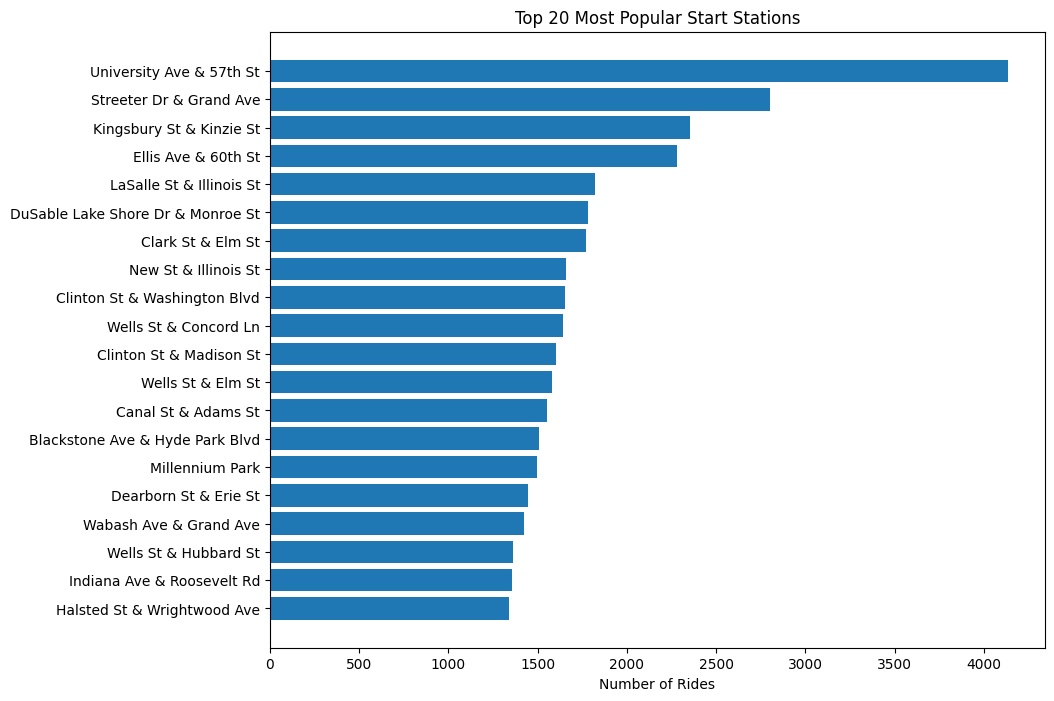

In [11]:
plt.figure(figsize=(10,8))
plt.barh(top_station.index,top_station.values)
plt.gca().invert_yaxis()
plt.title('Top 20 Most Popular Start Stations')
plt.xlabel('Number of Rides')

In [23]:
top_routes=(df['start_station_name'] + ' → ' + df['end_station_name']).value_counts().head(10)
top_routes

,count
Ellis Ave & 60th St → University Ave & 57th St,1222
University Ave & 57th St → Ellis Ave & 60th St,1097
University Ave & 57th St → Blackstone Ave & Hyde Park Blvd,563
University Ave & 57th St → Harper Ave & 59th St,539
Harper Ave & 59th St → University Ave & 57th St,525
Ellis Ave & 53rd St → University Ave & 57th St,483
University Ave & 57th St → Ellis Ave & 53rd St,470
Blackstone Ave & Hyde Park Blvd → University Ave & 57th St,453
Ellis Ave & 60th St → Ellis Ave & 55th St,375
Ellis Ave & 55th St → Ellis Ave & 60th St,328


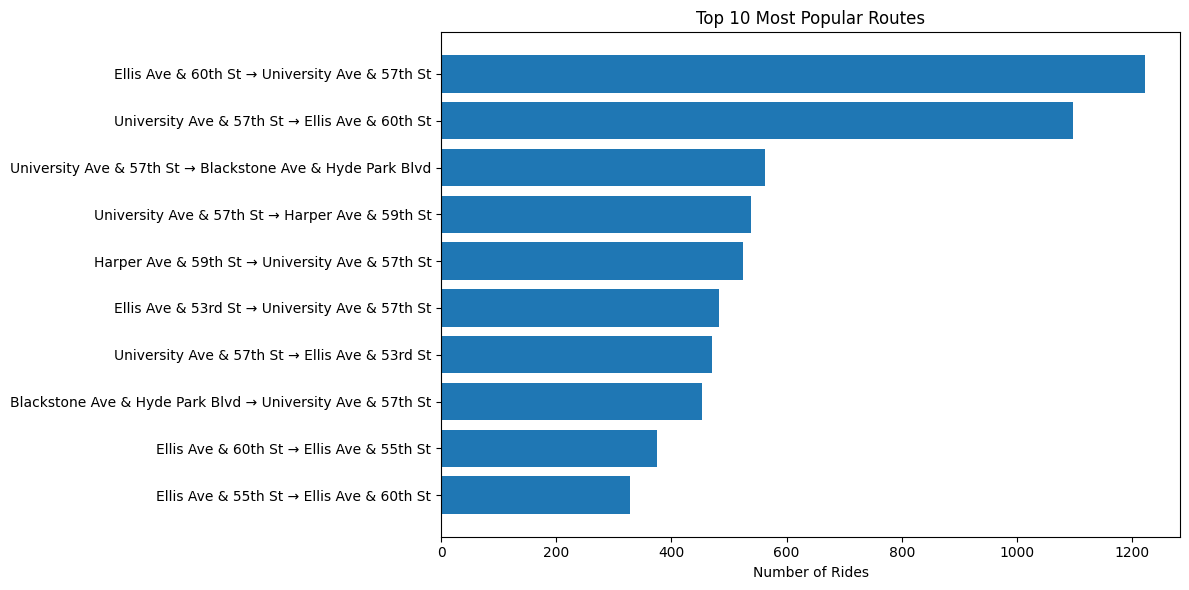

In [15]:
plt.figure(figsize=(12,6))
plt.barh(top_routes.index, top_routes.values)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Popular Routes')
plt.xlabel('Number of Rides')
plt.tight_layout()
plt.show()

In [16]:
import folium

In [17]:
station_data = df.groupby('start_station_name').agg(
    lat = ('start_lat', 'mean'),
    lng = ('start_lng', 'mean'),
    total_rides = ('ride_id', 'count')
).reset_index()

In [18]:
station_data.shape

(842, 4)

In [19]:
station_data.head()

,start_station_name,lat,lng,total_rides
0,2112 W Peterson Ave,41.991025,-87.683138,55
1,63rd St Beach,41.780799,-87.574950,54
2,900 W Harrison St,41.874753,-87.649808,660
3,Aberdeen St & Jackson Blvd,41.877735,-87.654808,550
4,Aberdeen St & Monroe St,41.880416,-87.655558,642


In [21]:
m = folium.Map(location=[41.88, -87.63], zoom_start=11)

for _, row in station_data.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=row['total_rides'] / 150,    # divide karo taaki circles bohot bade na ho
        color='blue',
        fill=True,
        popup=f"{row['start_station_name']}: {row['total_rides']} rides"
    ).add_to(m)

m


**Top Start Station:**

University Ave & 57th St 4134

Streeter Dr & Grand Ave	2804

Kingsbury St & Kinzie St	2355


**Most used paths**

Ellis Ave & 60th St → University Ave & 57th St	1222

University Ave & 57th St → Ellis Ave & 60th St	1097

University Ave & 57th St → Blackstone Ave & Hyde Park Blvd 563



**Insight**

Downtown Loop aur lakefront pe sabse bade circles — maximum bike traffic city center mein hai, suburbs mein minimal.